# Field Service Simulation - Core Module

This notebook implements request generation and admission, route planning, route execution, repair outcomes, carry-over, and the two dispatching policies described in the Project 2 problem statement.

## 1 - Imports, parameters, helper functions, and core simulation class

The constants below define the baseline system parameters from the problem description.

## Input Parameters

`MINUTES_PER_DAY` is the 480-minute working shift used for planning and execution checks. `MINUTES_PER_CALENDAR_DAY` is the 24-hour interval between the starts of consecutive working days.

In [24]:
#Muss unverändert bleiben
import simpy
import numpy as np

np.set_printoptions(precision=3)

# -----------------------------------------------------------------------------
# Simulation settings
# -----------------------------------------------------------------------------
MINUTES_PER_DAY = 480                  # length of the daily working shift
MINUTES_PER_CALENDAR_DAY = 24 * 60     # time between consecutive workday starts
PLANNING_SAFETY_MIN = 20              # safety allowance in every planning feasibility check
DAILY_TASK_LIMIT = 160                 # carryover has precedence; only new arrivals are admission-limited

# -----------------------------------------------------------------------------
# Service area
# -----------------------------------------------------------------------------
GRID_SIZE = 10                         # coordinates: 0, ..., 9
DEPOT = (5, 5)                         # baseline depot

# -----------------------------------------------------------------------------
# Travel-time model: fixed preparation time + triangular time per distance unit
# -----------------------------------------------------------------------------
TRAVEL_BASE_MIN = 5
TRAVEL_TRI_LOW = 5
TRAVEL_TRI_MODE = 7.5
TRAVEL_TRI_HIGH = 12
TRAVEL_MEAN_PER_UNIT = (TRAVEL_TRI_LOW + TRAVEL_TRI_MODE + TRAVEL_TRI_HIGH) / 3

# -----------------------------------------------------------------------------
# Demand
# -----------------------------------------------------------------------------
ARRIVALS_PER_DAY = 80
P_INSTALL = 0.60
P_REPAIR = 0.40

# -----------------------------------------------------------------------------
# Workforce
# -----------------------------------------------------------------------------
NUM_R1 = 3                              # Type R1 repair technicians
NUM_R2 = 3                              # Type R2 repair technicians
NUM_INSTALL = 3                         # dedicated installation technicians

# -----------------------------------------------------------------------------
# Service-time model: Gamma(shape alpha, scale theta)
# -----------------------------------------------------------------------------
INSTALL_GAMMA_SHAPE = 16
INSTALL_GAMMA_SCALE = 1.5
INSTALL_MEAN = INSTALL_GAMMA_SHAPE * INSTALL_GAMMA_SCALE
R1_REPAIR_GAMMA_SHAPE = 4
R1_REPAIR_GAMMA_SCALE = 5
R1_REPAIR_MEAN = R1_REPAIR_GAMMA_SHAPE * R1_REPAIR_GAMMA_SCALE
R2_REPAIR_GAMMA_SHAPE = 9
R2_REPAIR_GAMMA_SCALE = 5 / 3
R2_REPAIR_MEAN = R2_REPAIR_GAMMA_SHAPE * R2_REPAIR_GAMMA_SCALE
# -----------------------------------------------------------------------------
# Repair success
# -----------------------------------------------------------------------------
R1_SUCCESS_PROB = 0.90                  # first-attempt success probability for Type R1
# Type R2 repairs always succeed. Installations cannot fail.

# -----------------------------------------------------------------------------
# Priority scalar for dispatching
# -----------------------------------------------------------------------------
PRIORITY_SCALAR_INIT = {'installation': 0, 'repair': 1}
PRIORITY_SCALAR_MAX = 5



## Helper Functions

These functions implement the job representation, priority rule, Manhattan distance, and the expected and sampled travel and service times stated in the problem description.

In [25]:
#Muss unverändert bleiben
def make_job(job_id, day_created, location, request_type,
             carryover=False, second_attempt=False, waiting_days=0):
    """Create one request/job record used by the simulation.

    The original job identifier and creation day are retained when a job is
    carried over. ``second_attempt`` identifies failed Type R1 repairs that
    may subsequently be assigned only to a Type R2 technician.
    """
    return {
        'job_id': int(job_id),
        'day_created': int(day_created),
        'location': tuple(location),
        'request_type': request_type,
        'carryover': bool(carryover),
        'second_attempt': bool(second_attempt),
        'waiting_days': int(waiting_days),
    }


def priority_scalar(job):
    """Return the problem-defined priority, capped at 5.

    New installations start at 0, new repairs start at 1, and priority
    increases by one after each unresolved day.
    """
    init = PRIORITY_SCALAR_INIT.get(job['request_type'], 0)
    return min(init + job['waiting_days'], PRIORITY_SCALAR_MAX)


def manhattan(a, b):
    """Return the Manhattan distance between two grid locations."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def sample_travel_time(a, b, rng,
                       base=TRAVEL_BASE_MIN,
                       low=TRAVEL_TRI_LOW,
                       mode=TRAVEL_TRI_MODE,
                       high=TRAVEL_TRI_HIGH):
    """Sample actual travel time for one trip leg.

    Every leg includes the fixed preparation component. The stochastic time
    per grid-distance unit follows the triangular distribution specified in
    the problem description.
    """
    dist = manhattan(a, b)
    if dist == 0:
        return base
    return base + dist * rng.triangular(low, mode, high)


def expected_travel_time(a, b,
                         base=TRAVEL_BASE_MIN,
                         mean_per_unit=TRAVEL_MEAN_PER_UNIT):
    """Return expected trip-leg travel time used during planning and checks."""
    dist = manhattan(a, b)
    if dist == 0:
        return base
    return base + dist * mean_per_unit


def sample_service_time(tech_type, request_type, rng):
    """Sample actual service time for the given job-technician combination."""
    if request_type == 'installation':
        return rng.gamma(INSTALL_GAMMA_SHAPE, INSTALL_GAMMA_SCALE)
    if tech_type == 'R1':
        return rng.gamma(R1_REPAIR_GAMMA_SHAPE, R1_REPAIR_GAMMA_SCALE)
    if tech_type == 'R2':
        return rng.gamma(R2_REPAIR_GAMMA_SHAPE, R2_REPAIR_GAMMA_SCALE)
    raise ValueError('Dedicated installation technicians cannot perform repair jobs')


def expected_service_time(tech_type, request_type):
    """Return expected service time for planning and execution checks."""
    if request_type == 'installation':
        return INSTALL_MEAN
    if tech_type == 'R1':
        return R1_REPAIR_MEAN
    if tech_type == 'R2':
        return R2_REPAIR_MEAN
    raise ValueError('Dedicated installation technicians cannot perform repair jobs')

## Main Simulation Module

`FieldServiceSim` first creates the daily requests, admits carry-over jobs before new requests, constructs routes according to the selected policy, and then executes all technician routes concurrently. Planning uses expected times; execution uses sampled travel and service times.

In [26]:
#Muss unverändert bleiben
class FieldServiceSim:
    """Simulate the field-service process defined in the problem statement.

    The class covers request generation and admission, both dispatching
    policies, route execution, repair outcomes, and carry-over.

    Consecutive workdays start 24 hours apart in simulation time. Each workday
    still has the problem-defined 480-minute shift. After every technician has
    returned to the depot, the environment advances through the remaining
    inactive time until the start of the next calendar day.
    """

    def __init__(self, policy, seed, *,
                 sim_days,
                 arrivals_per_day,
                 p_repair,
                 p_install,
                 num_R1,
                 num_R2,
                 num_install,
                 R1_success,
                 depot,
                 travel_base,
                 travel_low,
                 travel_mode,
                 travel_high,
                 arrival_seed=None):
        """Initialize one simulation configuration and its random streams.

        ``seed`` controls travel times, service times, and repair outcomes.
        ``arrival_seed`` optionally controls request generation separately.
        The remaining arguments define the horizon, demand, workforce, depot,
        dispatching policy, and travel-time distribution.
        """

        # Validate the dispatching-policy name before any state is created.
        if policy not in {'priority', 'nearest'}:
            raise ValueError("policy must be either 'priority' or 'nearest'")

        # The simulation horizon must contain at least one working day.
        if int(sim_days) < 1:
            raise ValueError('sim_days must be at least 1')

        # A Poisson arrival rate cannot be negative.
        if arrivals_per_day < 0:
            raise ValueError('arrivals_per_day must be non-negative')

        # Request-type probabilities must be valid and form a full distribution.
        if not (0 <= p_repair <= 1 and 0 <= p_install <= 1):
            raise ValueError('request-type probabilities must lie in [0, 1]')
        if abs(p_repair + p_install - 1.0) > 1e-9:
            raise ValueError('p_repair and p_install must sum to 1')

        # Every technician-group size must be non-negative.
        if any(int(n) < 0 for n in (num_R1, num_R2, num_install)):
            raise ValueError('technician counts must be non-negative')

        # The Type R1 first-attempt success probability must be valid.
        if not 0 <= R1_success <= 1:
            raise ValueError('R1_success must lie in [0, 1]')

        # Validate the ordering of the triangular travel-time parameters.
        if not (0 <= travel_low <= travel_mode <= travel_high):
            raise ValueError('travel parameters must satisfy 0 <= low <= mode <= high')

        # The fixed preparation component of a trip cannot be negative.
        if travel_base < 0:
            raise ValueError('travel_base must be non-negative')

        # Convert the depot to an immutable coordinate pair and verify that it
        # lies on the 10 x 10 service grid.
        depot = tuple(depot)
        if len(depot) != 2 or any(not 0 <= int(c) < GRID_SIZE for c in depot):
            raise ValueError(f'depot coordinates must lie in 0, ..., {GRID_SIZE - 1}')

        # Store the general simulation, demand, workforce, and depot settings.
        self.policy = policy
        self.sim_days = int(sim_days)
        self.arrivals_per_day = float(arrivals_per_day)
        self.p_repair = float(p_repair)
        self.p_install = float(p_install)
        self.num_R1 = int(num_R1)
        self.num_R2 = int(num_R2)
        self.num_install = int(num_install)
        self.R1_success = float(R1_success)
        self.depot = depot

        # Store the travel distribution and calculate its expected value per
        # grid-distance unit for route planning and execution checks.
        self.travel_base = float(travel_base)
        self.travel_low = float(travel_low)
        self.travel_mode = float(travel_mode)
        self.travel_high = float(travel_high)
        self.travel_mean_per_unit = (self.travel_low + self.travel_mode + self.travel_high) / 3
        # Repeated expected-time calculations for the same trip leg are cached.
        self._expected_travel_cache = {}

        # Use separate random-number streams for request generation and for
        # route execution. If no arrival seed is given, seed also defines demand.
        if seed is None:
            seed = np.random.randint(1, 1001)
            arrival_rng = np.random.default_rng(seed if arrival_seed is None else arrival_seed)
            self.rng = np.random.default_rng(seed + 1)
        else:
            arrival_rng = np.random.default_rng(seed if arrival_seed is None else arrival_seed)
            self.rng = np.random.default_rng(seed + 1)

        # SimPy's environment stores and advances the simulation clock.
        self.env = simpy.Environment()
        # Job identifiers increase across the full simulation horizon.
        self.job_counter = 0

        # These structures connect each technician identifier to its type and
        # to the SimPy resource representing that technician's availability.
        self.tech_ids = []
        self.tech_types = {}
        self.tech_resources = {}

        # Create Type R1 technicians in identifier order: R1-1, R1-2, ...
        for i in range(self.num_R1):
            tid = f'R1-{i + 1}'
            # Add the identifier to the common technician sequence.
            self.tech_ids.append(tid)
            # Store the technician type for eligibility and service-time rules.
            self.tech_types[tid] = 'R1'
            # Capacity one prevents simultaneous activities by one technician.
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Create Type R2 technicians in identifier order: R2-1, R2-2, ...
        for i in range(self.num_R2):
            tid = f'R2-{i + 1}'
            self.tech_ids.append(tid)
            self.tech_types[tid] = 'R2'
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Create dedicated installation technicians: I-1, I-2, ...
        for i in range(self.num_install):
            tid = f'I-{i + 1}'
            self.tech_ids.append(tid)
            self.tech_types[tid] = 'install'
            self.tech_resources[tid] = simpy.Resource(self.env, capacity=1)

        # Requests are generated before the run so their identifiers establish
        # the deterministic order used for admission and policy tie-breaking.
        self._pregenerated_arrivals = {}
        # Generate one ordered request list for every simulated day.
        for d in range(1, self.sim_days + 1):
            # Sample the day's request count from the Poisson distribution.
            n = int(arrival_rng.poisson(self.arrivals_per_day))
            # Collect requests in generation and job-identifier order.
            jobs = []
            # Generate the type and location of each request independently.
            for _ in range(n):
                # A request is a repair with probability p_repair; otherwise
                # it is an installation because the two probabilities sum to 1.
                rtype = 'repair' if arrival_rng.random() < self.p_repair else 'installation'
                # Both coordinates are sampled uniformly from 0, ..., 9.
                loc = (int(arrival_rng.integers(0, GRID_SIZE)),
                       int(arrival_rng.integers(0, GRID_SIZE)))
                # Assign the next unique identifier and create the request.
                self.job_counter += 1
                jobs.append(make_job(self.job_counter, d, loc, rtype))
            # Save the complete ordered request list for day d.
            self._pregenerated_arrivals[d] = jobs

        # Initialize state that changes as run() advances through the days.
        self.day = 0
        self.day_start = 0.0
        self.day_end = 0.0
        self.carryover = []

    def expected_travel_time(self, a, b):
        """Return and cache expected travel time for trip leg ``a`` to ``b``."""
        # Coordinates define the cache key. Travel parameters are constant for
        # the lifetime of this simulation object.
        key = (a, b)
        # Calculate a value only the first time this trip leg is requested.
        if key not in self._expected_travel_cache:
            self._expected_travel_cache[key] = expected_travel_time(
                a, b, self.travel_base, self.travel_mean_per_unit
            )
        # Return either the newly calculated value or the cached value.
        return self._expected_travel_cache[key]

    def sample_travel_time(self, a, b):
        """Sample actual travel time using this simulation's random stream."""
        # Forward the configured fixed and triangular parameters to the helper.
        return sample_travel_time(a, b, self.rng, self.travel_base,
                                  self.travel_low, self.travel_mode, self.travel_high)

    def _generate_daily_arrivals(self):
        """Return copies of the requests generated for the current day."""
        # Copies prevent later carry-over changes from modifying the original
        # pregenerated request list.
        return [dict(j) for j in self._pregenerated_arrivals[self.day]]

    def _limit_daily_arrivals(self, carryover, new_jobs):
        """Apply the 160-task daily admission limit to new arrivals.

        Carry-over jobs always have precedence and are never discarded. If the
        carry-over count is at least the limit, no new request is admitted.
        The admitted new-job list is truncated to the remaining capacity, so the
        daily active pool is limited to DAILY_TASK_LIMIT by construction.
        """
        # Carry-over jobs occupy the active pool before new requests enter it.
        available_slots = max(0, DAILY_TASK_LIMIT - len(carryover))
        # New requests are already ordered by their unique job identifiers.
        accepted = new_jobs[:available_slots]
        # Requests after the capacity cut do not enter planning or carry-over.
        dropped = new_jobs[available_slots:]
        return accepted, dropped

    def _eligible(self, tech_id, job):
        """Apply technician eligibility rules from the problem description."""
        # Read the technician group once for the checks below.
        ttype = self.tech_types[tech_id]
        # Installations may be performed by every technician group, so only
        # repair requests require additional eligibility restrictions.
        if job['request_type'] == 'repair':
            # Dedicated installation technicians never perform repairs.
            if ttype == 'install':
                return False
            # A failed first attempt becomes an R2-only second attempt.
            if job['second_attempt'] and ttype != 'R2':
                return False
        # No restriction above excluded this technician-job combination.
        return True

    def _repair_technicians(self):
        """Return R2 technicians first, followed by R1 technicians."""
        # Dedicated installation technicians are excluded from this phase.
        # The tuple sort key first orders technician type and then identifier.
        return sorted(
            [tid for tid in self.tech_ids if self.tech_types[tid] != 'install'],
            key=lambda t: (0 if self.tech_types[t] == 'R2' else 1, t)
        )

    def _planning_times(self, tech_id, current_location, job):
        """Return expected travel, service, and return times for one assignment."""
        travel_to_job = self.expected_travel_time(current_location, job['location'])
        service_time = expected_service_time(
            self.tech_types[tech_id], job['request_type']
        )
        return_to_depot = self.expected_travel_time(job['location'], self.depot)
        return travel_to_job, service_time, return_to_depot

    def _is_planning_feasible(self, tech_id, current_location, remaining_time, job):
        """Check the planning rule for one technician-job combination."""
        travel_to_job, service_time, return_to_depot = self._planning_times(
            tech_id, current_location, job
        )
        required_time = (
            travel_to_job
            + service_time
            + return_to_depot
            + PLANNING_SAFETY_MIN
        )
        return required_time <= remaining_time

    def _installation_candidates(self, pool, current_location):
        """Return installation jobs ordered by distance and then job ID."""
        ranked_jobs = []
        for job in pool:
            if job['request_type'] == 'installation':
                distance = self.expected_travel_time(current_location, job['location'])
                ranked_jobs.append((distance, job['job_id'], job))
        ranked_jobs.sort(key=lambda item: (item[0], item[1]))
        return [item[2] for item in ranked_jobs]

    def _select_priority_job(self, pool, repair_techs, tech_pos):
        """Select the next job according to the priority-policy job ranking."""
        highest_priority = max(priority_scalar(job) for job in pool)
        ranked_jobs = []

        for job in pool:
            if priority_scalar(job) != highest_priority:
                continue

            eligible_techs = [
                tid for tid in repair_techs if self._eligible(tid, job)
            ]
            if eligible_techs:
                nearest_distance = min(
                    self.expected_travel_time(tech_pos[tid], job['location'])
                    for tid in eligible_techs
                )
            else:
                nearest_distance = float('inf')

            ranked_jobs.append((nearest_distance, job['job_id'], job))

        ranked_jobs.sort(key=lambda item: (item[0], item[1]))
        return ranked_jobs[0][2]

    def _priority_technicians(self, job, repair_techs, tech_pos):
        """Return eligible technicians in the priority-policy search order."""
        # Store one sortable entry for every technician who may perform this job.
        ranked_techs = []
        # Check all Type R2 and Type R1 technicians considered in phase 2.
        for tid in repair_techs:
            # Exclude technicians who cannot perform the request. For example,
            # second-attempt repairs can be performed only by Type R2.
            if not self._eligible(tid, job):
                continue

            # Type R2 receives rank 0 and Type R1 receives rank 1. Therefore,
            # every eligible R2 technician is considered before every R1.
            type_order = 0 if self.tech_types[tid] == 'R2' else 1
            # Within the same technician type, rank by expected travel from the
            # technician's current planned location to the selected job.
            distance = self.expected_travel_time(tech_pos[tid], job['location'])
            # The technician identifier is the final deterministic tie-breaker.
            ranked_techs.append((type_order, distance, tid))

        # Tuple sorting applies type, distance, and technician-ID order in sequence.
        ranked_techs.sort()
        # Remove the ranking values and return only the ordered technician IDs.
        return [item[2] for item in ranked_techs]

    def _nearest_candidates(self, pool, tech_id, current_location):
        """Return eligible jobs in the nearest-policy ranking order."""
        # Store each eligible job together with its three ranking values.
        ranked_jobs = []
        # Examine every unassigned job still available in the shared pool.
        for job in pool:
            # Remove jobs that this technician cannot perform. Dedicated repair
            # rules include the Type R2 requirement for second attempts.
            if not self._eligible(tech_id, job):
                continue

            # Distance from the technician's current planned location is the
            # primary ranking criterion of the nearest policy.
            distance = self.expected_travel_time(current_location, job['location'])
            # Store negative priority because Python sorts smaller values first;
            # this makes a larger job priority appear before a smaller priority.
            ranked_jobs.append((
                distance,
                -priority_scalar(job),
                # Job identifier is the final deterministic tie-breaker.
                job['job_id'],
                # Keep the complete job record so it can be returned after sorting.
                job,
            ))

        # Sort first by distance, then by higher priority, and finally by job ID.
        ranked_jobs.sort(key=lambda item: (item[0], item[1], item[2]))
        # Remove the ranking values and return the jobs in assignment-check order.
        return [item[3] for item in ranked_jobs]

    def _build_day_plan(self, pending_jobs):
        """Construct all technician routes using expected times.

        The common first phase fills dedicated installation-technician routes.
        The remaining jobs are then assigned using either the job-first priority
        policy or the technician-first nearest policy. Jobs left in the returned
        pool are carried over to the next day.
        """
        # Create one initially empty planned route for every technician.
        plan = {tid: [] for tid in self.tech_ids}
        # At the beginning of planning, every technician has the complete
        # 480-minute shift available.
        remaining_time = {tid: MINUTES_PER_DAY for tid in self.tech_ids}
        # Each technician's planned route starts at the central depot.
        tech_pos = {tid: self.depot for tid in self.tech_ids}
        # Copy the pending jobs because assigned jobs are removed from this pool.
        pool = list(pending_jobs)

        # ------------------------------------------------------------------
        # Common phase: dedicated installation technicians
        # ------------------------------------------------------------------
        # Select the dedicated installation technicians in identifier order.
        install_techs = [tid for tid in self.tech_ids if self.tech_types[tid] == 'install']
        # Construct the complete route of one installation technician before
        # continuing with the next installation technician.
        for tid in install_techs:
            # Continue adding installations until no further job can be assigned.
            while True:
                # Rank the remaining installation jobs by distance from this
                # technician's current planned location, followed by job ID.
                candidates = self._installation_candidates(pool, tech_pos[tid])
                # Stop this route when no installation job remains.
                if not candidates:
                    break

                # The flag remains False if all ranked candidates are infeasible.
                assigned = False
                # Check the ranked jobs and assign the first feasible one.
                for job in candidates:
                    # Feasibility includes expected travel to the job, expected
                    # service, expected return travel, and the safety allowance.
                    if self._is_planning_feasible(
                        tid, tech_pos[tid], remaining_time[tid], job
                    ):
                        # Obtain the expected travel and service time that will
                        # be deducted after accepting this job.
                        travel_to_job, service_time, _ = self._planning_times(
                            tid, tech_pos[tid], job
                        )
                        # Append the job to this technician's planned route.
                        plan[tid].append(job)
                        # Remove the assigned job so no other technician receives it.
                        pool.remove(job)
                        # Return travel and the safety allowance remain reserved
                        # through later feasibility checks and are not deducted here.
                        remaining_time[tid] -= travel_to_job + service_time
                        # Future distances for this route start from this customer.
                        tech_pos[tid] = job['location']
                        assigned = True
                        # Add only one job in this while-loop iteration, then
                        # rank the remaining jobs again from the new location.
                        break

                # If none of the remaining installations is feasible, the
                # current installation technician's route is complete.
                if not assigned:
                    break

        # The second planning phase uses only R2 and R1 technicians. The returned
        # order places all R2 technicians before all R1 technicians.
        repair_techs = self._repair_technicians()

        # ------------------------------------------------------------------
        # Priority policy: select a job first, then search for a technician
        # ------------------------------------------------------------------
        if self.policy == 'priority':
            # Collect selected jobs that no eligible technician can accept.
            unassigned = []
            # Select and process one job at a time until the pool is empty.
            while pool:
                # Select the highest-priority job. Within the same priority,
                # rank by distance to the nearest eligible technician and job ID.
                job = self._select_priority_job(pool, repair_techs, tech_pos)
                # Remove the selected job before attempting its assignment. It
                # will enter either a technician route or the unassigned list.
                pool.remove(job)

                # Rank eligible technicians for this job: R2 before R1, then
                # distance from the current planned location, then technician ID.
                placed = False
                ordered_techs = self._priority_technicians(
                    job, repair_techs, tech_pos
                )
                # Assign the selected job to the first feasible technician in
                # the required technician order.
                for tid in ordered_techs:
                    if self._is_planning_feasible(
                        tid, tech_pos[tid], remaining_time[tid], job
                    ):
                        # Calculate the expected travel and service time consumed
                        # by adding this job to the selected route.
                        travel_to_job, service_time, _ = self._planning_times(
                            tid, tech_pos[tid], job
                        )
                        # Update the technician's route and planned route state.
                        plan[tid].append(job)
                        remaining_time[tid] -= travel_to_job + service_time
                        tech_pos[tid] = job['location']
                        placed = True
                        # The job has been assigned, so no later technician is checked.
                        break

                # A job that is infeasible for every eligible technician remains
                # unassigned for this day.
                if not placed:
                    unassigned.append(job)

            # Return all planned routes and the jobs not assigned by this policy.
            return plan, unassigned

        # ------------------------------------------------------------------
        # Nearest policy: complete one technician route at a time
        # ------------------------------------------------------------------
        elif self.policy == 'nearest':
            # Complete each R2 route first and then each R1 route. One route is
            # completed before planning begins for the next technician.
            for tid in repair_techs:
                # Continue adding jobs until this technician has no feasible job.
                while True:
                    # Rank this technician's eligible jobs by distance, followed
                    # by higher priority and then job ID.
                    candidates = self._nearest_candidates(
                        pool, tid, tech_pos[tid]
                    )
                    # End this route when no eligible job remains in the pool.
                    if not candidates:
                        break

                    # Search the ranked list for the first feasible job.
                    assigned = False
                    for job in candidates:
                        if self._is_planning_feasible(
                            tid, tech_pos[tid], remaining_time[tid], job
                        ):
                            # Obtain the expected time consumed by this assignment.
                            travel_to_job, service_time, _ = self._planning_times(
                                tid, tech_pos[tid], job
                            )
                            # Append the job, remove it from the shared pool, and
                            # update the route's remaining time and location.
                            plan[tid].append(job)
                            pool.remove(job)
                            remaining_time[tid] -= travel_to_job + service_time
                            tech_pos[tid] = job['location']
                            assigned = True
                            # Re-rank the pool from the newly planned location.
                            break

                    # If every eligible job is infeasible, this technician's
                    # route is complete and planning moves to the next technician.
                    if not assigned:
                        break

            # Jobs still in the pool were not assigned by the nearest policy.
            return plan, pool

    def _run_tech_route(self, tech_id, route):
        """Execute one technician's planned route with sampled times.

        Before each planned job, feasibility is checked from the technician's
        actual current location using expected travel, service, and return time.
        If a job cannot be attempted, it is added to the next day's carry-over.
        The route does not stop immediately: every later assigned job is checked in route
        order because a later location may still be feasible. After all remaining
        jobs have been checked, the technician returns from the last attempted
        job location to the depot using sampled travel time.
        """
        # Read this technician's type for service-time and repair-outcome rules.
        ttype = self.tech_types[tech_id]
        # Retrieve the capacity-one resource representing this technician.
        resource = self.tech_resources[tech_id]
        # Every technician begins the route at the central depot.
        pos = self.depot

        # Follow the planned job sequence. A non-attempted job is skipped, but
        # every later job in the route is still checked in sequence.
        for job in route:
            # Actual elapsed working time includes sampled travel and service.
            elapsed = self.env.now - self.day_start
            # The execution feasibility check uses the remaining 480-minute shift.
            remaining = MINUTES_PER_DAY - elapsed
            # Expected travel is measured from the last actually attempted job,
            # or from the depot if no job has yet been attempted.
            t_to_exp = self.expected_travel_time(pos, job['location'])
            # Expected service depends on both technician type and request type.
            t_svc_exp = expected_service_time(ttype, job['request_type'])
            # Reserve enough expected time to return from this job to the depot.
            t_back_exp = self.expected_travel_time(job['location'], self.depot)

            # The execution check does not use the 20-minute planning allowance.
            # A skipped job does not change the technician's actual position.
            if t_to_exp + t_svc_exp + t_back_exp > remaining:
                # Store the original job so run() can recreate it as carry-over
                # with one additional unresolved day.
                self._day_not_attempted.append(job)
                # Keep the same actual position and check the next planned job.
                continue

            # Each technician has one route process, so the resource only models
            # that the technician can execute one activity at a time.
            req = resource.request()
            # Wait until the technician resource is available.
            yield req

            # Sample and execute the trip from the actual current position.
            t_travel = self.sample_travel_time(pos, job['location'])
            yield self.env.timeout(t_travel)

            # Sample and execute service at the customer location.
            t_svc = sample_service_time(ttype, job['request_type'], self.rng)
            yield self.env.timeout(t_svc)

            # Installations, R2 repairs, and second-attempt repairs complete.
            # Only a first-attempt R1 repair can fail.
            result = 'completed'
            if job['request_type'] == 'repair' and ttype == 'R1' and not job['second_attempt']:
                # Success occurs when the random draw is below R1_success.
                if self.rng.random() >= self.R1_success:
                    result = 'failed_first_attempt'

            # Service occurred at this customer, regardless of repair success,
            # so this becomes the technician's actual current position.
            pos = job['location']

            if result == 'failed_first_attempt':
                # A failed Type R1 repair becomes a second-attempt repair for
                # the next day and can then be assigned only to Type R2.
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    'repair', carryover=True, second_attempt=True,
                    waiting_days=job['waiting_days'] + 1
                ))

            # Release the technician after this job's travel and service finish.
            resource.release(req)

        # If no job was attempted, pos is already the depot and no trip occurs.
        # Otherwise this is the stochastic return leg from the last attempted job.
        if pos != self.depot:
            # Sample the final trip leg from the last attempted job to the depot.
            t_return = self.sample_travel_time(pos, self.depot)
            yield self.env.timeout(t_return)

    def run(self):
        """Run all simulated days and return the final carry-over list.

        The environment first waits for every technician route to finish and
        return to the depot. It then advances through the inactive remainder of
        the 24-hour calendar day before the next day's requests are processed.
        """
        # Simulate working days in chronological order.
        for day in range(1, self.sim_days + 1):
            # Expose the current day to arrival generation and other methods.
            self.day = day
            # Collect planned jobs that fail the execution feasibility check.
            self._day_not_attempted = []

            # Because the preceding iteration advances to the next calendar day,
            # consecutive day starts are normally exactly 1,440 minutes apart.
            # Record the calendar time at which this working day begins.
            self.day_start = self.env.now
            # day_end marks the nominal end of the 480-minute working shift.
            self.day_end = self.day_start + MINUTES_PER_DAY
            # The following working day begins 24 hours after this one.
            next_day_start = self.day_start + MINUTES_PER_CALENDAR_DAY

            # Save the unresolved jobs entering from the preceding day.
            prev_carry = self.carryover
            # Rebuild carry-over from this day's failures and unresolved jobs.
            self.carryover = []
            # Retrieve this day's pregenerated requests in job-ID order.
            generated_jobs = self._generate_daily_arrivals()
            # Admit carry-over first and then as many new requests as capacity allows.
            accepted_jobs, _ = self._limit_daily_arrivals(
                prev_carry, generated_jobs
            )
            # Only carry-over and accepted new requests enter route planning.
            pool = list(prev_carry) + list(accepted_jobs)

            # Requests beyond the active-pool capacity do not enter planning
            # or carry-over.
            plan, unassigned = self._build_day_plan(pool)

            # Start one concurrent SimPy process for every non-empty route.
            route_events = []
            for tid in self.tech_ids:
                # A technician with an empty route remains at the depot.
                if plan[tid]:
                    # Store the process event so all routes can be awaited together.
                    route_events.append(
                        self.env.process(self._run_tech_route(tid, plan[tid]))
                    )

            # Complete every started route, including its sampled return trip.
            if route_events:
                self.env.run(until=self.env.all_of(route_events))

            # Recreate every non-attempted job as next-day carry-over.
            for job in self._day_not_attempted:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            # Recreate every job left unassigned during planning as carry-over.
            for job in unassigned:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            # Advance through the non-working part of the calendar day. Actual
            # sampled durations may produce overtime beyond 480 minutes. In the
            # extremely unlikely case that a route exceeds 24 hours, no negative
            # waiting time is added and the following day starts when it finishes.
            if self.env.now < next_day_start:
                # Move the clock to the exact start of the following calendar day.
                self.env.run(until=next_day_start)

        # Return the unresolved jobs remaining after the final simulated day.
        return self.carryover



## Smoke Test

This cell creates and runs a three-day simulation for each dispatching policy.

In [27]:
#Muss unverändet bleiben
# Run both dispatching policies for three days to verify the core module.
for policy in ('priority', 'nearest'):
    smoke_sim = FieldServiceSim(
        policy=policy,
        seed=None,
        sim_days=30,
        arrivals_per_day=ARRIVALS_PER_DAY,
        p_repair=P_REPAIR,
        p_install=P_INSTALL,
        num_R1=NUM_R1,
        num_R2=NUM_R2,
        num_install=NUM_INSTALL,
        R1_success=R1_SUCCESS_PROB,
        depot=DEPOT,
        travel_base=TRAVEL_BASE_MIN,
        travel_low=TRAVEL_TRI_LOW,
        travel_mode=TRAVEL_TRI_MODE,
        travel_high=TRAVEL_TRI_HIGH,
    )
    remaining_jobs = smoke_sim.run()
    print(f"Environment time after {policy} simulation: {smoke_sim.env.now:.2f} minutes corresponding to {smoke_sim.day} days simulated")
    print(f"Total jobs processed: {smoke_sim.job_counter}, Total carry-over jobs: {len(remaining_jobs)}")

Environment time after priority simulation: 43200.00 minutes corresponding to 30 days simulated
Total jobs processed: 2399, Total carry-over jobs: 0
Environment time after nearest simulation: 43200.00 minutes corresponding to 30 days simulated
Total jobs processed: 2417, Total carry-over jobs: 2


## ab hier beginnt eigener Code ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

In [28]:
# NEU: eigene Zelle
# FieldServiceSim selbst wird NICHT verändert. Diese Subklasse überschreibt _run_tech_route() und run()
# übernommene Planungs- und Ausführungslogik ist identisch zum Core, ergänzt nur um Protokollierung

class FieldServiceSimWithMetrics(FieldServiceSim):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # LOG: Container für alle pro Tag/Job/Techniker gesammelten Rohdaten
        self.daily_records = []     # eine Zeile pro simuliertem Tag (Z_d, D_d, ...)
        self.job_records = []       # eine Zeile pro Job-Ereignis (Status, Ort, Tag)
        self.tech_day_records = []  # eine Zeile pro Techniker pro Tag

    def _run_tech_route(self, tech_id, route):
        #Identisch zur Core-Implementierung, zusätzlich mit Protokollierung.
        ttype = self.tech_types[tech_id]
        resource = self.tech_resources[tech_id]
        pos = self.depot

        # LOG: Technikerspezifische Tageszähler
        travel_time_sum = 0.0
        service_time_sum = 0.0
        n_completed = 0
        n_failed = 0
        n_not_attempted = 0

        for job in route:
            elapsed = self.env.now - self.day_start
            remaining = MINUTES_PER_DAY - elapsed
            t_to_exp = self.expected_travel_time(pos, job['location'])
            t_svc_exp = expected_service_time(ttype, job['request_type'])
            t_back_exp = self.expected_travel_time(job['location'], self.depot)

            if t_to_exp + t_svc_exp + t_back_exp > remaining:
                self._day_not_attempted.append(job)
                n_not_attempted += 1
                # LOG: "not attempted"-Ereignis
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=tech_id, status='not_attempted',
                    day_created=job['day_created'],
                ))
                continue

            req = resource.request()
            yield req

            t_travel = self.sample_travel_time(pos, job['location'])
            yield self.env.timeout(t_travel)
            travel_time_sum += t_travel

            t_svc = sample_service_time(ttype, job['request_type'], self.rng)
            yield self.env.timeout(t_svc)
            service_time_sum += t_svc

            result = 'completed'
            if job['request_type'] == 'repair' and ttype == 'R1' and not job['second_attempt']:
                if self.rng.random() >= self.R1_success:
                    result = 'failed_first_attempt'

            pos = job['location']

            if result == 'failed_first_attempt':
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    'repair', carryover=True, second_attempt=True,
                    waiting_days=job['waiting_days'] + 1
                ))
                n_failed += 1
            else:
                n_completed += 1

            # LOG: "completed" / "failed_first_attempt"-Ereignis
            self.job_records.append(dict(
                day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                location=job['location'], tech_id=tech_id, status=result,
                day_created=job['day_created'], second_attempt=job['second_attempt'],
            ))

            resource.release(req)

        if pos != self.depot:
            t_return = self.sample_travel_time(pos, self.depot)
            yield self.env.timeout(t_return)
            travel_time_sum += t_return

        # LOG: Techniker-Tagesbilanz (inkl. evtl. Überstunden über 480 Min.)
        working_time = self.env.now - self.day_start
        self.tech_day_records.append(dict(
            day=self.day, tech_id=tech_id, tech_type=ttype,
            working_time=working_time, travel_time=travel_time_sum,
            service_time=service_time_sum, n_completed=n_completed,
            n_failed=n_failed, n_not_attempted=n_not_attempted,
            overtime=max(0.0, working_time - MINUTES_PER_DAY),
        ))

    def run(self):
        #Identisch zur Core-run()-Methode, zusätzlich mit Tagesprotokollierung.
        for day in range(1, self.sim_days + 1):
            self.day = day
            self._day_not_attempted = []

            self.day_start = self.env.now
            self.day_end = self.day_start + MINUTES_PER_DAY
            next_day_start = self.day_start + MINUTES_PER_CALENDAR_DAY

            prev_carry = self.carryover
            self.carryover = []
            generated_jobs = self._generate_daily_arrivals()
            # LOG: dropped_jobs statt "_" mitführen, um D_d und "not accepted" zu protokollieren
            accepted_jobs, dropped_jobs = self._limit_daily_arrivals(
                prev_carry, generated_jobs
            )
            pool = list(prev_carry) + list(accepted_jobs)

            plan, unassigned = self._build_day_plan(pool)

            # LOG: Techniker mit leerer Route bleiben am Depot -> Arbeitszeit 0
            idle_techs = [tid for tid in self.tech_ids if not plan[tid]]

            route_events = []
            for tid in self.tech_ids:
                if plan[tid]:
                    route_events.append(
                        self.env.process(self._run_tech_route(tid, plan[tid]))
                    )

            if route_events:
                self.env.run(until=self.env.all_of(route_events))

            # LOG: untätige Techniker protokollieren
            for tid in idle_techs:
                self.tech_day_records.append(dict(
                    day=self.day, tech_id=tid, tech_type=self.tech_types[tid],
                    working_time=0.0, travel_time=0.0, service_time=0.0,
                    n_completed=0, n_failed=0, n_not_attempted=0, overtime=0.0,
                ))

            for job in self._day_not_attempted:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))

            for job in unassigned:
                self.carryover.append(make_job(
                    job['job_id'], job['day_created'], job['location'],
                    job['request_type'], carryover=True,
                    second_attempt=job['second_attempt'],
                    waiting_days=job['waiting_days'] + 1
                ))
                # LOG: "not assigned"-Ereignis
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=None, status='not_assigned',
                    day_created=job['day_created'],
                ))

            # LOG: "not accepted"-Ereignisse (gehen in D_d ein)
            for job in dropped_jobs:
                self.job_records.append(dict(
                    day=self.day, job_id=job['job_id'], request_type=job['request_type'],
                    location=job['location'], tech_id=None, status='not_accepted',
                    day_created=job['day_created'],
                ))

            # LOG: Z_d = Summe der Prioritäten im End-Carryover + 5 * D_d
            Z_d = sum(priority_scalar(j) for j in self.carryover) + 5 * len(dropped_jobs)
            self.daily_records.append(dict(
                day=self.day, Z_d=Z_d, D_d=len(dropped_jobs),
                carryover_count=len(self.carryover),
                generated=len(generated_jobs), accepted_new=len(accepted_jobs),
            ))

            if self.env.now < next_day_start:
                self.env.run(until=next_day_start)

        return self.carryover

In [29]:
# NEU: Validierung: Subklasse muss sich identisch zur Core-Klasse verhalten, -> gleicher Seed, gleiche Routen, gleiches Carry-over
for policy in ('priority', 'nearest'):
    sim = FieldServiceSimWithMetrics(
        policy=policy, seed=42, sim_days=10,
        arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
        num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
        R1_success=R1_SUCCESS_PROB, depot=DEPOT,
        travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
        travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
    )
    remaining = sim.run()
    print(policy, '| Carryover:', len(remaining),
          '| Tagesdatensätze:', len(sim.daily_records),
          '| Job-Ereignisse:', len(sim.job_records))

priority | Carryover: 0 | Tagesdatensätze: 10 | Job-Ereignisse: 819
nearest | Carryover: 0 | Tagesdatensätze: 10 | Job-Ereignisse: 807


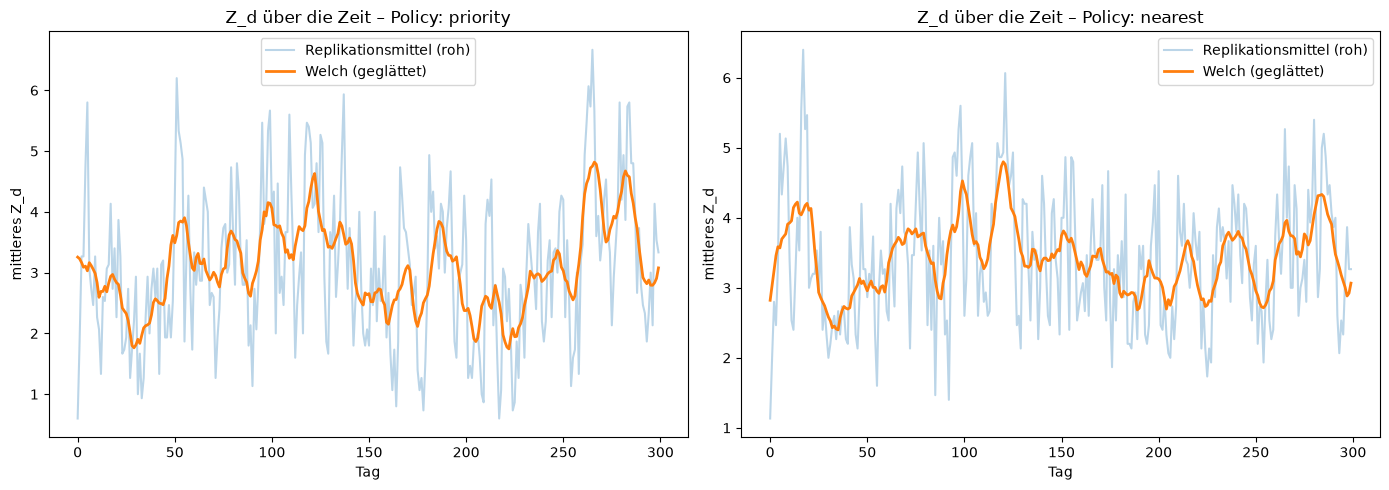

In [30]:
# NEU: Aufgabe 1 Warm-up-Bestimmung via Welch's Method
import matplotlib.pyplot as plt

def run_replications_for_warmup(policy, n_reps=15, sim_days=300, base_seed=1000):
    """Mehrere unabhängige Replikationen, gibt Z_d-Zeitreihe je Replikation zurück."""
    all_Zd = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        Zd_series = [rec['Z_d'] for rec in sim.daily_records]
        all_Zd.append(Zd_series)
    return np.array(all_Zd)  # shape (n_reps, sim_days)

def welch_moving_average(data, window=5):
    """data: (n_reps, n_days) -> mittelt über Replikationen, dann gleitendes Fenster."""
    mean_across_reps = data.mean(axis=0)
    smoothed = np.array([
        mean_across_reps[max(0, t - window): t + window + 1].mean()
        for t in range(len(mean_across_reps))
    ])
    return mean_across_reps, smoothed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, policy in zip(axes, ('priority', 'nearest')):
    data = run_replications_for_warmup(policy, n_reps=15, sim_days=300)
    raw, smoothed = welch_moving_average(data, window=5)
    ax.plot(raw, alpha=0.3, label='Replikationsmittel (roh)')
    ax.plot(smoothed, linewidth=2, label='Welch (geglättet)')
    ax.set_title(f'Z_d über die Zeit – Policy: {policy}')
    ax.set_xlabel('Tag')
    ax.set_ylabel('mittleres Z_d')
    ax.legend()
plt.tight_layout()
plt.show()

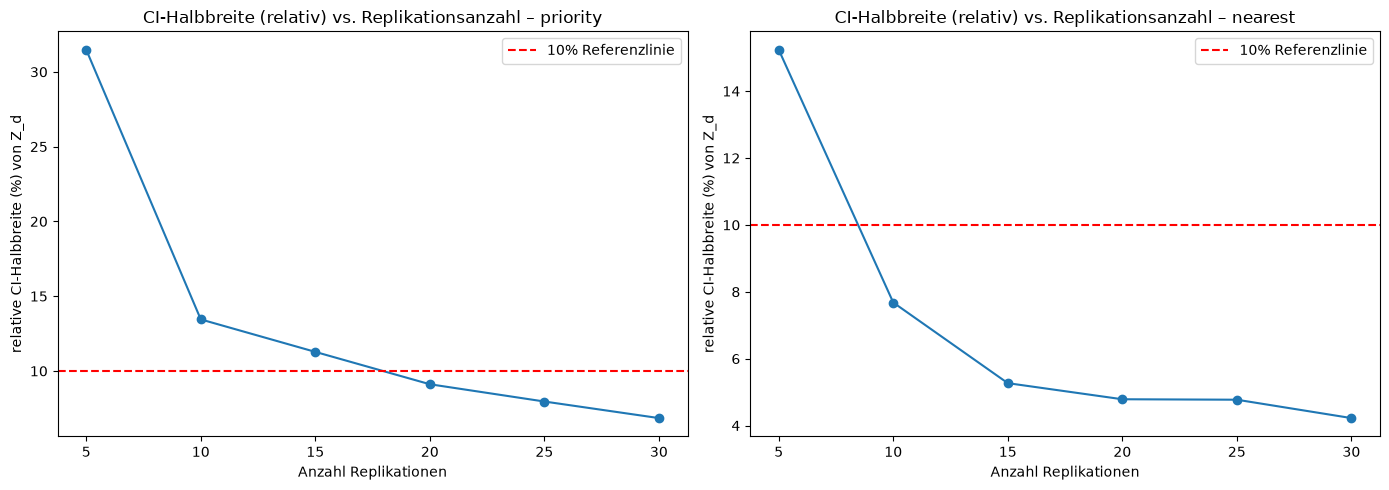

priority: mean Z_d = 3.065, 95%-CI = [2.855, 3.275], n_reps = 30
nearest: mean Z_d = 3.377, 95%-CI = [3.234, 3.519], n_reps = 30


In [31]:
# NEU: Aufgabe 1 (Fortsetzung) Replikationsanzahl über CI-Breite bestimmen
from scipy import stats

WARMUP_DAYS = 40          # auf Basis der Welch-Analyse festgelegt
EVAL_HORIZON_DAYS = 200   # Tage NACH dem Warm-up, die ausgewertet werden
SIM_DAYS = WARMUP_DAYS + EVAL_HORIZON_DAYS

def run_replications_eval(policy, n_reps, sim_days=SIM_DAYS, base_seed=2000):
    """Führt n_reps Replikationen aus und gibt den mittleren Z_d (nach Warm-up)
    je Replikation zurück (eine Zahl pro Replikation)."""
    rep_means = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        Zd_after_warmup = [
            rec['Z_d'] for rec in sim.daily_records if rec['day'] > WARMUP_DAYS
        ]
        rep_means.append(np.mean(Zd_after_warmup))
    return np.array(rep_means)

def ci_half_width(data, confidence=0.95):
    """95%-Konfidenzintervall-Halbbreite des Mittelwerts (t-Verteilung)."""
    n = len(data)
    if n < 2:
        return np.nan
    se = stats.sem(data)
    t_val = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return t_val * se

# Replikationszahlen, die wir testen wollen
rep_counts = [5, 10, 15, 20, 25, 30]
MAX_REPS = max(rep_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results = {}

for ax, policy in zip(axes, ('priority', 'nearest')):
    # Einmal die maximale Anzahl Replikationen ziehen, dann Teilmengen auswerten
    # (spart Rechenzeit gegenüber separatem Neulauf je rep_count)
    all_rep_means = run_replications_eval(policy, n_reps=MAX_REPS)
    results[policy] = all_rep_means

    half_widths = []
    rel_half_widths = []
    for n in rep_counts:
        subset = all_rep_means[:n]
        hw = ci_half_width(subset)
        half_widths.append(hw)
        rel_half_widths.append(hw / subset.mean() * 100)  # relative Breite in %

    ax.plot(rep_counts, rel_half_widths, marker='o')
    ax.axhline(10, color='red', linestyle='--', label='10% Referenzlinie')
    ax.set_title(f'CI-Halbbreite (relativ) vs. Replikationsanzahl – {policy}')
    ax.set_xlabel('Anzahl Replikationen')
    ax.set_ylabel('relative CI-Halbbreite (%) von Z_d')
    ax.legend()

plt.tight_layout()
plt.show()

# Übersichtstabelle der finalen Schätzwerte mit MAX_REPS Replikationen
for policy in ('priority', 'nearest'):
    data = results[policy]
    hw = ci_half_width(data)
    print(f"{policy}: mean Z_d = {data.mean():.3f}, "
          f"95%-CI = [{data.mean()-hw:.3f}, {data.mean()+hw:.3f}], "
          f"n_reps = {len(data)}")

In [32]:
# NEU: Finale Konfiguration für Aufgaben 2–9
WARMUP_DAYS = 40
EVAL_HORIZON_DAYS = 200
SIM_DAYS = WARMUP_DAYS + EVAL_HORIZON_DAYS   # = 240
N_REPLICATIONS = 20

In [34]:
# NEU – Aufgabe 2: KPI-Berechnung für beide Policies (Baseline-Performance)
import pandas as pd

def compute_kpis_for_sim(sim, warmup_days=WARMUP_DAYS):
    """Berechnet alle im PDF definierten KPIs aus einem Simulationslauf,
    unter Ausschluss der Warm-up-Tage."""

    # Daten nach Warm-up filtern
    daily = [r for r in sim.daily_records if r['day'] > warmup_days]
    jobs = [r for r in sim.job_records if r['day'] > warmup_days]
    tech_days = [r for r in sim.tech_day_records if r['day'] > warmup_days]

    # 1) Average daily service performance score (Z_d)
    avg_Zd = np.mean([r['Z_d'] for r in daily])

    # 2) First-time fix rate für Repairs
    # Erstversuche: request_type == 'repair' und second_attempt == False
    # second_attempt wird in job_records nur für completed/failed gesetzt,
    # daher über "second_attempt"-Feld filtern (existiert für alle Repair-Events)
    first_attempts = [
        r for r in jobs
        if r['request_type'] == 'repair'
        and r.get('second_attempt', False) == False
        and r['status'] in ('completed', 'failed_first_attempt')
    ]
    successful_first = [r for r in first_attempts if r['status'] == 'completed']
    first_time_fix_rate = (
        len(successful_first) / len(first_attempts) if first_attempts else np.nan
    )

    # 3) Wahrscheinlichkeit eines fehlgeschlagenen ersten Reparaturversuchs -
    prob_failed_first = (
        1 - first_time_fix_rate if not np.isnan(first_time_fix_rate) else np.nan
    )

    # 4) Durchschnittliche tägliche Reisezeit pro Techniker-Typ
    df_tech = pd.DataFrame(tech_days)
    avg_travel_by_type = df_tech.groupby('tech_type')['travel_time'].mean().to_dict()

    # 5) Auslastung pro Techniker-Typ
    df_tech['utilization'] = df_tech['working_time'] / MINUTES_PER_DAY
    avg_utilization_by_type = df_tech.groupby('tech_type')['utilization'].mean().to_dict()

    # 6) Workload Balance (AAD von der Tagesdurchschnitts-Auslastung)
    aad_per_day = []
    for day, group in df_tech.groupby('day'):
        day_mean_util = group['utilization'].mean()
        aad = (group['utilization'] - day_mean_util).abs().mean()
        aad_per_day.append(aad)
    workload_aad = np.mean(aad_per_day)

    # 7) Durchschnittliche Wartezeit (Ankunft -> erfolgreicher Abschluss)
    # Nur Jobs, die letztendlich erfolgreich abgeschlossen wurden (completed).
    # second-attempt-Erfolge zählen als der Tag des erfolgreichen 2. Versuchs.
    completed_jobs = [r for r in jobs if r['status'] == 'completed']
    waiting_days_list = [r['day'] - r['day_created'] for r in completed_jobs]
    avg_waiting_days = np.mean(waiting_days_list) if waiting_days_list else np.nan
    # Umrechnung in Minuten (anhand des 24h-Kalendertags) zur Einordnung
    avg_waiting_minutes = avg_waiting_days * MINUTES_PER_CALENDAR_DAY

    return dict(
        avg_Zd=avg_Zd,
        first_time_fix_rate=first_time_fix_rate,
        prob_failed_first_attempt=prob_failed_first,
        avg_travel_R1=avg_travel_by_type.get('R1', np.nan),
        avg_travel_R2=avg_travel_by_type.get('R2', np.nan),
        avg_travel_install=avg_travel_by_type.get('install', np.nan),
        util_R1=avg_utilization_by_type.get('R1', np.nan),
        util_R2=avg_utilization_by_type.get('R2', np.nan),
        util_install=avg_utilization_by_type.get('install', np.nan),
        workload_aad=workload_aad,
        avg_waiting_days=avg_waiting_days,
        avg_waiting_minutes=avg_waiting_minutes,
    )


def run_kpi_replications(policy, n_reps=N_REPLICATIONS, sim_days=SIM_DAYS, base_seed=3000):
    """Führt n_reps Replikationen aus und gibt eine Liste von KPI-Dicts zurück."""
    all_kpis = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()
        all_kpis.append(compute_kpis_for_sim(sim))
    return pd.DataFrame(all_kpis)


def summarize_kpis(df_kpis, confidence=0.95):
    """Mittelwert + CI-Halbbreite je Spalte (KPI) über die Replikationen."""
    summary = {}
    for col in df_kpis.columns:
        data = df_kpis[col].dropna().values
        mean = data.mean()
        hw = ci_half_width(data, confidence=confidence)
        summary[col] = (mean, hw)
    return summary


# Beide Policies auswerten
kpi_results = {}
for policy in ('priority', 'nearest'):
    df_kpis = run_kpi_replications(policy)
    kpi_results[policy] = summarize_kpis(df_kpis)

# Ergebnistabelle bauen
rows = []
kpi_labels = {
    'avg_Zd': 'Avg. daily service score (Z_d)',
    'first_time_fix_rate': 'First-time fix rate (Repairs)',
    'prob_failed_first_attempt': 'P(failed first attempt)',
    'avg_travel_R1': 'Avg. daily travel time R1 (min)',
    'avg_travel_R2': 'Avg. daily travel time R2 (min)',
    'avg_travel_install': 'Avg. daily travel time Install (min)',
    'util_R1': 'Utilization R1',
    'util_R2': 'Utilization R2',
    'util_install': 'Utilization Install',
    'workload_aad': 'Workload balance (AAD)',
    'avg_waiting_days': 'Avg. waiting time (days)',
    'avg_waiting_minutes': 'Avg. waiting time (min)',
}

for key, label in kpi_labels.items():
    row = {'KPI': label}
    for policy in ('priority', 'nearest'):
        mean, hw = kpi_results[policy][key]
        row[f'{policy} (mean)'] = round(mean, 3)
        row[f'{policy} (95% CI half-width)'] = round(hw, 3)
    rows.append(row)

kpi_table = pd.DataFrame(rows)
kpi_table

,KPI,priority (mean),priority (95% CI half-width),nearest (mean),nearest (95% CI half-width)
0,Avg. daily service score (Z_d),3.051,0.349,3.385,0.225
1,First-time fix rate (Repairs),0.992,0.001,0.978,0.001
2,P(failed first attempt),0.008,0.001,0.022,0.001
3,Avg. daily travel time R1 (min),212.193,2.425,163.885,2.109
4,Avg. daily travel time R2 (min),273.403,0.578,233.523,0.524
5,Avg. daily travel time Install (min),199.311,0.521,200.424,0.490
6,Utilization R1,0.733,0.009,0.569,0.008
7,Utilization R2,0.918,0.001,0.921,0.001
8,Utilization Install,0.921,0.001,0.920,0.001
9,Workload balance (AAD),0.105,0.003,0.182,0.004


In [ ]:
# NEU – Aufgabe 3: Schätzung der Wahrscheinlichkeit eines fehlgeschlagenen
# ersten Reparaturversuchs P(failed first attempt)
#
# Definition: Anteil der Reparatur-Erstversuche, die fehlschlagen.
# Nur R1-Erstversuche KÖNNEN fehlschlagen (mit Wahrscheinlichkeit 1 - R1_success = 0.10).
# R2-Erstversuche gelingen immer. Daher gilt analytisch:
#     P(failed first attempt) = P(Erstversuch durch R1) * (1 - R1_success)
# Diese Zerlegung nutzen wir als Sanity-Check: Der simulierte Schätzer und
# das Produkt aus R1-Anteil * 0.10 müssen (bis auf Stichprobenrauschen) übereinstimmen.

def estimate_failed_first_attempt(policy, n_reps=N_REPLICATIONS,
                                  sim_days=SIM_DAYS, base_seed=4000,
                                  warmup_days=WARMUP_DAYS):
    """Schätzt P(failed first attempt) pro Replikation.

    Rückgabe: DataFrame mit einer Zeile pro Replikation:
      - p_failed:    Anteil fehlgeschlagener Erstversuche
      - share_r1:    Anteil der Erstversuche, die von R1 durchgeführt wurden
      - p_analytic:  share_r1 * (1 - R1_success)  (analytische Kontrolle)
      - n_first:     Anzahl ausgewerteter Erstversuche (Stichprobengröße)
    """
    rows = []
    for r in range(n_reps):
        sim = FieldServiceSimWithMetrics(
            policy=policy, seed=base_seed + r, sim_days=sim_days,
            arrivals_per_day=ARRIVALS_PER_DAY, p_repair=P_REPAIR, p_install=P_INSTALL,
            num_R1=NUM_R1, num_R2=NUM_R2, num_install=NUM_INSTALL,
            R1_success=R1_SUCCESS_PROB, depot=DEPOT,
            travel_base=TRAVEL_BASE_MIN, travel_low=TRAVEL_TRI_LOW,
            travel_mode=TRAVEL_TRI_MODE, travel_high=TRAVEL_TRI_HIGH,
        )
        sim.run()

        # Nur Erstversuche nach dem Warm-up betrachten:
        # request_type == 'repair', kein second_attempt, und tatsächlich
        # durchgeführt (Status completed oder failed_first_attempt).
        first_attempts = [
            rec for rec in sim.job_records
            if rec['day'] > warmup_days
            and rec['request_type'] == 'repair'
            and rec.get('second_attempt', False) == False
            and rec['status'] in ('completed', 'failed_first_attempt')
        ]

        n_first = len(first_attempts)
        n_failed = sum(1 for rec in first_attempts
                       if rec['status'] == 'failed_first_attempt')
        # Anteil der Erstversuche, die ein R1-Techniker durchgeführt hat
        n_by_r1 = sum(1 for rec in first_attempts
                      if rec['tech_id'] is not None
                      and sim.tech_types[rec['tech_id']] == 'R1')

        p_failed = n_failed / n_first if n_first else np.nan
        share_r1 = n_by_r1 / n_first if n_first else np.nan

        rows.append(dict(
            replication=r + 1,
            n_first=n_first,
            p_failed=p_failed,
            share_r1=share_r1,
            p_analytic=share_r1 * (1 - R1_SUCCESS_PROB),
        ))
    return pd.DataFrame(rows)


# Beide Policies auswerten und Ergebnistabelle mit 95%-CI bauen
task3_results = {}
task3_rows = []
for policy in ('priority', 'nearest'):
    df = estimate_failed_first_attempt(policy)
    task3_results[policy] = df

    mean_p = df['p_failed'].mean()
    hw_p = ci_half_width(df['p_failed'].values)
    mean_share = df['share_r1'].mean()
    mean_analytic = df['p_analytic'].mean()

    task3_rows.append(dict(
        Policy=policy,
        **{
            'P(failed first attempt)': round(mean_p, 4),
            '95%-CI': f'[{mean_p - hw_p:.4f}, {mean_p + hw_p:.4f}]',
            'Anteil Erstversuche durch R1': round(mean_share, 4),
            'Analytisch: R1-Anteil * 0.10': round(mean_analytic, 4),
            'Erstversuche pro Replikation (Ø)': round(df['n_first'].mean(), 1),
        }
    ))

task3_table = pd.DataFrame(task3_rows)
print('Aufgabe 3 – Wahrscheinlichkeit eines fehlgeschlagenen ersten Reparaturversuchs')
print(f'(n = {N_REPLICATIONS} Replikationen, {EVAL_HORIZON_DAYS} Auswertungstage nach {WARMUP_DAYS} Tagen Warm-up)\n')
task3_table

Aufgabe 3 – Wahrscheinlichkeit eines fehlgeschlagenen ersten Reparaturversuchs
(n = 20 Replikationen, 200 Auswertungstage nach 40 Tagen Warm-up)



,Policy,P(failed first attempt),95%-CI,Anteil Erstversuche durch R1,Analytisch: R1-Anteil * 0.10,Erstversuche pro Replikation (Ø)
0,priority,0.0086,"[0.0078, 0.0094]",0.0843,0.0084,6389.0
1,nearest,0.0224,"[0.0212, 0.0235]",0.2295,0.0229,6388.9
